In [1]:
# !wget "https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47&confirm=t"
# !mv "$(ls -Art | head -1)" mal.zip

!pip install gdown
#upgrade
!pip install --upgrade gdown

import gdown
# a file
url = "https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47"
output = "mal.zip"
gdown.download(url, output)

!unzip -o mal.zip
!rm mal_data/train/.DS_Store
!rm mal_data/test/.DS_Store

  Attempting uninstall: gdown
    Found existing installation: gdown 5.2.2
    Uninstalling gdown-5.2.2:
      Successfully uninstalled gdown-5.2.2


Downloading...
From (original): https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47
From (redirected): https://drive.google.com/uc?id=1YQiwQ2XmCNQoQv5G898cngZYuv00gW47&confirm=t&uuid=4b6a5aa3-5506-4615-a287-e35c8b19d1be
To: /content/mal.zip
100%|██████████| 2.44G/2.44G [01:03<00:00, 38.6MB/s]


Streaming output truncated to the last 5000 lines.
  inflating: mal_data/train/Zbot/49f9785d5a42b3daa95d7d91ab077e669f7116c8.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._49f9785d5a42b3daa95d7d91ab077e669f7116c8.exe  
  inflating: mal_data/train/Zbot/daf40516a7c465ebbcaea190707a04bf6af1a2e5.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._daf40516a7c465ebbcaea190707a04bf6af1a2e5.exe  
  inflating: mal_data/train/Zbot/42547c95702e0c5c846e4e5ecac6db6ac8c22175.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._42547c95702e0c5c846e4e5ecac6db6ac8c22175.exe  
  inflating: mal_data/train/Zbot/39940afa60287af35d90db68fc6396d0c20b74d0.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._39940afa60287af35d90db68fc6396d0c20b74d0.exe  
  inflating: mal_data/train/Zbot/d7c51263bd3beec0fcefa2d94589530450b5e1bd.exe  
  inflating: __MACOSX/mal_data/train/Zbot/._d7c51263bd3beec0fcefa2d94589530450b5e1bd.exe  
  inflating: mal_data/train/Zbot/21891ae5ca1d7146a8df57aa7c89b7234b099ff7.exe  
  inflating: _

In [2]:
import os
import pickle

import numpy as np

import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
import os
import os.path
from typing import Any, Callable, cast, Dict, List, Optional, Tuple, Union
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
    """Finds the class folders in a dataset.
    See :class:`DatasetFolder` for details.
    """
    classes = sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())
    if not classes:
        raise FileNotFoundError(f"Couldn't find any class folder in {directory}.")

    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    return classes, class_to_idx

_,class_to_idx = find_classes("mal_data/train")


class MalwareDataset(Dataset):
    def __init__(self, data_path, input_length = 4096, transform=False):
        self.data_path = data_path
        self.input_length = input_length
        _,self.class_to_idx = find_classes(data_path)
        self.malware_files = []
        available_classes = set()
        for target_class in sorted(class_to_idx.keys()):
            class_index = class_to_idx[target_class]
            target_dir = os.path.join(data_path, target_class)
            if not os.path.isdir(target_dir):
                continue
            for root, _, fnames in sorted(os.walk(target_dir, followlinks=True)):
                for fname in sorted(fnames):
                    path = os.path.join(root, fname)
                    item = path, class_index
                    self.malware_files.append(item)

    def __getitem__(self, index):
        item = self.malware_files[index]
        with open(item[0], "rb") as f:
            tmp = [i+1 for i in f.read()[:self.input_length]]
            tmp = tmp+[0]*(self.input_length-len(tmp))
        return np.array(tmp), item[1]

    def __len__(self):
        return len(self.malware_files)



In [3]:
import torch
from torch import nn
from torch.nn import functional as F


# neural network
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()

        self.classifier = nn.Sequential(
            nn.Conv1d(1,4,19,5),
            nn.MaxPool1d(4),
            nn.Flatten(),
            nn.Linear(48, 6)
        )

    def forward(self, x):
        out = self.classifier(x)

        return out


model=ConvNet()
model.cuda()
model.train()


lr=0.001
num_epochs=10
batch_size = 16
input_len = 256 # Number of bytes read from application files (.exe)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

train_data = MalwareDataset("mal_data/train",input_length = input_len)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
test_data = MalwareDataset("mal_data/test",input_length = input_len)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

loss_list = []
acc_list = []
total_step = len(train_loader)

for epoch in range(num_epochs):
  for i, (samples, labels) in enumerate(train_loader):
    samples = samples.type(torch.FloatTensor).cuda()
    labels = labels.cuda()

    outputs = model(samples.unsqueeze(1))

    loss = criterion(outputs, labels)
    loss_list.append(loss.item())

    # Backprop and percform Adam optimisation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Track the accuracy
    total = labels.size(0)
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    acc_list.append(correct / total)

    if (i%200 == 0):
      print('Epoch [{}/{}], Step [{}/{}], Loss: {:.4f}, Accuracy: {:.2f}%'
              .format(epoch + 1, num_epochs, i, total_step, loss.item(),
                      (correct / total) * 100))



Epoch [1/10], Step [0/437], Loss: 43.2948, Accuracy: 6.25%
Epoch [1/10], Step [200/437], Loss: 6.1383, Accuracy: 50.00%
Epoch [1/10], Step [400/437], Loss: 3.1572, Accuracy: 75.00%
Epoch [2/10], Step [0/437], Loss: 1.9699, Accuracy: 75.00%
Epoch [2/10], Step [200/437], Loss: 1.5526, Accuracy: 68.75%
Epoch [2/10], Step [400/437], Loss: 0.8605, Accuracy: 81.25%
Epoch [3/10], Step [0/437], Loss: 0.2709, Accuracy: 87.50%
Epoch [3/10], Step [200/437], Loss: 0.4641, Accuracy: 81.25%
Epoch [3/10], Step [400/437], Loss: 0.1716, Accuracy: 93.75%
Epoch [4/10], Step [0/437], Loss: 1.2966, Accuracy: 81.25%
Epoch [4/10], Step [200/437], Loss: 0.6954, Accuracy: 81.25%
Epoch [4/10], Step [400/437], Loss: 0.1248, Accuracy: 93.75%
Epoch [5/10], Step [0/437], Loss: 0.2342, Accuracy: 87.50%
Epoch [5/10], Step [200/437], Loss: 0.1976, Accuracy: 93.75%
Epoch [5/10], Step [400/437], Loss: 0.2880, Accuracy: 87.50%
Epoch [6/10], Step [0/437], Loss: 0.2536, Accuracy: 93.75%
Epoch [6/10], Step [200/437], Loss: 

In [4]:
model.eval()
with torch.no_grad():
  correct = 0
  total = 0
  for samples, labels in test_loader:
      samples = samples.type(torch.FloatTensor).cuda()
      labels = labels.cuda()

      outputs = model(samples.unsqueeze(1))
      _, predicted = torch.max(outputs.data, 1)
      total += labels.size(0)
      correct += (predicted == labels).sum().item()

print(
  'Accuracy of the model on the test samples: {} %'.format((correct / total) * 100))

Accuracy of the model on the test samples: 93.21297225008358 %


Text(0.5, 1.0, 'loss')

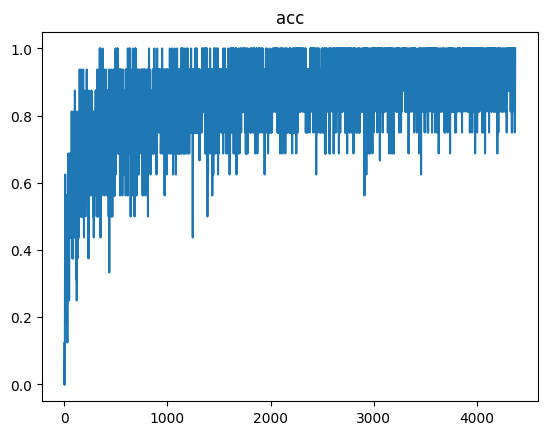

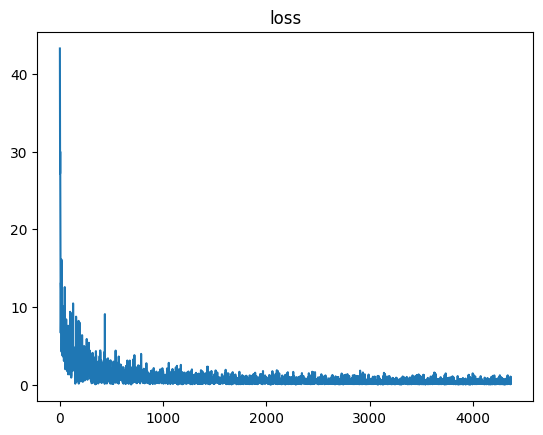

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(acc_list)
plt.title('acc')

plt.figure()
plt.plot(loss_list)
plt.title('loss')



In [6]:
# ==============================
# Adversarial Attack: FGSM
# ==============================

import torch
import numpy as np
import matplotlib.pyplot as plt

def fgsm_attack(model, samples, labels, epsilon):
    """
    Creates adversarial samples using the Fast Gradient Sign Method (FGSM).

    Args:
        model: trained PyTorch model
        samples: batch of input byte arrays
        labels: true labels for the batch
        epsilon: perturbation strength

    Returns:
        adv_samples: adversarially modified samples
    """

    # Make sure samples are float tensors on GPU
    samples = samples.clone().detach().type(torch.FloatTensor).cuda()
    labels = labels.cuda()

    # Enable gradient tracking for the input
    samples.requires_grad = True

    # Forward pass
    outputs = model(samples.unsqueeze(1))
    loss = criterion(outputs, labels)

    # Backward pass to calculate gradients with respect to input bytes
    model.zero_grad()
    loss.backward()

    # FGSM perturbation: epsilon * sign(gradient)
    perturbation = epsilon * samples.grad.sign()
    adv_samples = samples + perturbation

    # Keep byte values within the same valid range used by the dataset.
    # The original dataset code maps byte values to 1-256 and uses 0 for padding.
    adv_samples = torch.clamp(adv_samples, 0, 256)

    return adv_samples.detach()

In [7]:
# ==============================
# Attack Evaluation Function
# ==============================

def evaluate_fgsm_attack(model, test_loader, epsilon):
    """
    Evaluates the model on clean samples and adversarial samples.

    Args:
        model: trained PyTorch model
        test_loader: DataLoader for test data
        epsilon: perturbation strength

    Returns:
        Dictionary with clean accuracy, adversarial accuracy, and attack success rate.
    """

    model.eval()

    total = 0
    correct_clean = 0
    correct_adv = 0
    successful_attacks = 0

    for samples, labels in test_loader:
        samples = samples.type(torch.FloatTensor).cuda()
        labels = labels.cuda()

        # --------------------------
        # Clean prediction
        # --------------------------
        clean_outputs = model(samples.unsqueeze(1))
        _, clean_predicted = torch.max(clean_outputs.data, 1)

        # --------------------------
        # Generate adversarial samples
        # --------------------------
        adv_samples = fgsm_attack(model, samples, labels, epsilon)

        # --------------------------
        # Adversarial prediction
        # --------------------------
        adv_outputs = model(adv_samples.unsqueeze(1))
        _, adv_predicted = torch.max(adv_outputs.data, 1)

        # --------------------------
        # Metrics
        # --------------------------
        total += labels.size(0)
        correct_clean += (clean_predicted == labels).sum().item()
        correct_adv += (adv_predicted == labels).sum().item()

        # Attack success:
        # only count samples the model originally classified correctly,
        # but then misclassified after the adversarial perturbation.
        successful_attacks += ((clean_predicted == labels) & (adv_predicted != labels)).sum().item()

    clean_accuracy = correct_clean / total * 100
    adversarial_accuracy = correct_adv / total * 100

    if correct_clean > 0:
        attack_success_rate = successful_attacks / correct_clean * 100
    else:
        attack_success_rate = 0

    return {
        "epsilon": epsilon,
        "clean_accuracy": clean_accuracy,
        "adversarial_accuracy": adversarial_accuracy,
        "attack_success_rate": attack_success_rate
    }

In [8]:
# ==============================
# Run FGSM Attack for Multiple Epsilon Values
# ==============================

epsilons = [0, 1, 2, 5, 10, 20, 40]

attack_results = []

for eps in epsilons:
    results = evaluate_fgsm_attack(model, test_loader, eps)
    attack_results.append(results)

    print(f"Epsilon: {results['epsilon']}")
    print(f"Clean Accuracy: {results['clean_accuracy']:.2f}%")
    print(f"Adversarial Accuracy: {results['adversarial_accuracy']:.2f}%")
    print(f"Attack Success Rate: {results['attack_success_rate']:.2f}%")
    print("-" * 40)

Epsilon: 0
Clean Accuracy: 93.21%
Adversarial Accuracy: 93.21%
Attack Success Rate: 0.00%
----------------------------------------
Epsilon: 1
Clean Accuracy: 93.21%
Adversarial Accuracy: 77.63%
Attack Success Rate: 16.71%
----------------------------------------
Epsilon: 2
Clean Accuracy: 93.21%
Adversarial Accuracy: 49.08%
Attack Success Rate: 47.35%
----------------------------------------
Epsilon: 5
Clean Accuracy: 93.21%
Adversarial Accuracy: 10.00%
Attack Success Rate: 89.28%
----------------------------------------
Epsilon: 10
Clean Accuracy: 93.21%
Adversarial Accuracy: 0.77%
Attack Success Rate: 99.18%
----------------------------------------
Epsilon: 20
Clean Accuracy: 93.21%
Adversarial Accuracy: 0.53%
Attack Success Rate: 99.43%
----------------------------------------
Epsilon: 40
Clean Accuracy: 93.21%
Adversarial Accuracy: 0.00%
Attack Success Rate: 100.00%
----------------------------------------


In [9]:
# ==============================
# Display Results Table
# ==============================

import pandas as pd

results_df = pd.DataFrame(attack_results)
results_df

,epsilon,clean_accuracy,adversarial_accuracy,attack_success_rate
0,0,93.212972,93.212972,0.000000
1,1,93.212972,77.632899,16.714491
2,2,93.212972,49.080575,47.345768
3,5,93.212972,9.996657,89.275466
4,10,93.212972,0.768974,99.175036
5,20,93.212972,0.534938,99.426112
6,40,93.212972,0.000000,100.000000


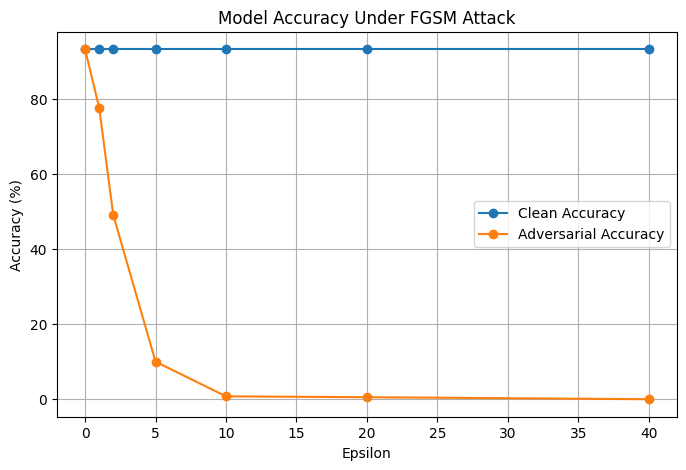

In [10]:
# ==============================
# Plot Accuracy Degradation
# ==============================

plt.figure(figsize=(8, 5))
plt.plot(results_df["epsilon"], results_df["clean_accuracy"], marker="o", label="Clean Accuracy")
plt.plot(results_df["epsilon"], results_df["adversarial_accuracy"], marker="o", label="Adversarial Accuracy")
plt.title("Model Accuracy Under FGSM Attack")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

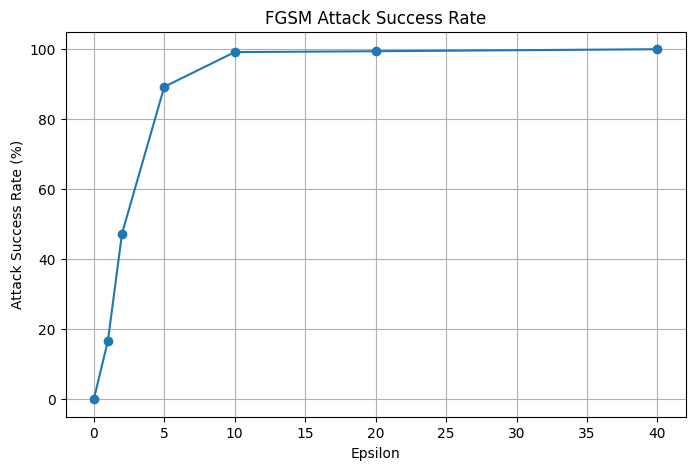

In [11]:
# ==============================
# Plot Attack Success Rate
# ==============================

plt.figure(figsize=(8, 5))
plt.plot(results_df["epsilon"], results_df["attack_success_rate"], marker="o")
plt.title("FGSM Attack Success Rate")
plt.xlabel("Epsilon")
plt.ylabel("Attack Success Rate (%)")
plt.grid(True)
plt.show()

In [13]:
# ==============================
# Small Epsilon Sweep
# ==============================

small_epsilons = [0, 0.25, 0.5, 1, 1.5, 2, 3, 4, 5]

small_attack_results = []

for eps in small_epsilons:
    results = evaluate_fgsm_attack(model, test_loader, eps)
    small_attack_results.append(results)

small_results_df = pd.DataFrame(small_attack_results)
small_results_df

,epsilon,clean_accuracy,adversarial_accuracy,attack_success_rate
0,0.00,93.212972,93.212972,0.000000
1,0.25,93.212972,91.240388,2.116212
2,0.50,93.212972,88.030759,5.559541
3,1.00,93.212972,77.632899,16.714491
4,1.50,93.212972,63.724507,31.635581
5,2.00,93.212972,49.080575,47.345768
6,3.00,93.212972,28.050819,69.906743
7,4.00,93.212972,16.616516,82.173601
8,5.00,93.212972,9.996657,89.275466


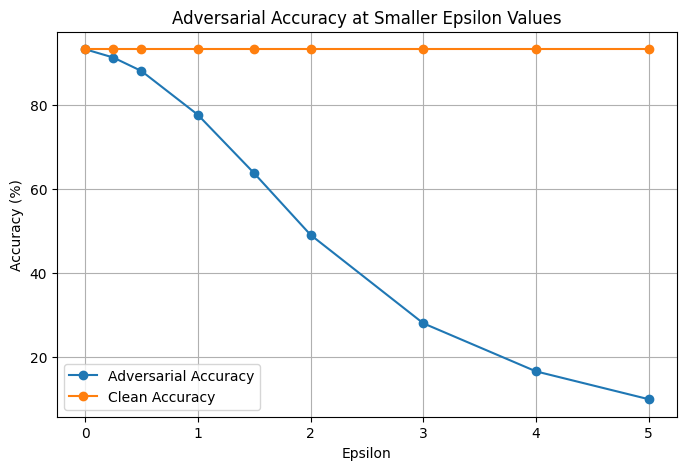

In [14]:
# ==============================
# Plot Small Epsilon Accuracy Degradation
# ==============================

plt.figure(figsize=(8, 5))
plt.plot(
    small_results_df["epsilon"],
    small_results_df["adversarial_accuracy"],
    marker="o",
    label="Adversarial Accuracy"
)
plt.plot(
    small_results_df["epsilon"],
    small_results_df["clean_accuracy"],
    marker="o",
    label="Clean Accuracy"
)
plt.title("Adversarial Accuracy at Smaller Epsilon Values")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# ==============================
# Random Noise Baseline Attack
# ==============================

def random_noise_attack(samples, epsilon):
    samples = samples.clone().detach().type(torch.FloatTensor).cuda()

    # Random perturbation between -epsilon and +epsilon
    noise = torch.empty_like(samples).uniform_(-epsilon, epsilon)

    noisy_samples = samples + noise
    noisy_samples = torch.clamp(noisy_samples, 0, 256)

    return noisy_samples.detach()


def evaluate_random_noise_attack(model, test_loader, epsilon):
    model.eval()

    total = 0
    correct_noisy = 0

    for samples, labels in test_loader:
        samples = samples.type(torch.FloatTensor).cuda()
        labels = labels.cuda()

        noisy_samples = random_noise_attack(samples, epsilon)

        outputs = model(noisy_samples.unsqueeze(1))
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct_noisy += (predicted == labels).sum().item()

    noisy_accuracy = correct_noisy / total * 100

    return noisy_accuracy

In [16]:
# ==============================
# Compare FGSM Against Random Noise
# ==============================

comparison_results = []

for eps in [0, 1, 2, 5, 10]:
    fgsm_result = evaluate_fgsm_attack(model, test_loader, eps)
    random_acc = evaluate_random_noise_attack(model, test_loader, eps)

    comparison_results.append({
        "epsilon": eps,
        "clean_accuracy": fgsm_result["clean_accuracy"],
        "fgsm_accuracy": fgsm_result["adversarial_accuracy"],
        "random_noise_accuracy": random_acc
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df

,epsilon,clean_accuracy,fgsm_accuracy,random_noise_accuracy
0,0,93.212972,93.212972,93.212972
1,1,93.212972,77.632899,93.346707
2,2,93.212972,49.080575,93.112671
3,5,93.212972,9.996657,93.045804
4,10,93.212972,0.768974,92.544300


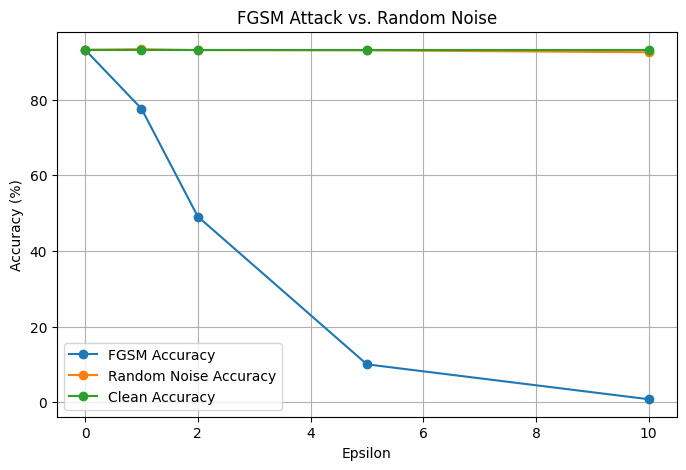

In [17]:
# ==============================
# Plot FGSM vs Random Noise
# ==============================

plt.figure(figsize=(8, 5))
plt.plot(
    comparison_df["epsilon"],
    comparison_df["fgsm_accuracy"],
    marker="o",
    label="FGSM Accuracy"
)
plt.plot(
    comparison_df["epsilon"],
    comparison_df["random_noise_accuracy"],
    marker="o",
    label="Random Noise Accuracy"
)
plt.plot(
    comparison_df["epsilon"],
    comparison_df["clean_accuracy"],
    marker="o",
    label="Clean Accuracy"
)
plt.title("FGSM Attack vs. Random Noise")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# ==============================
# Clean and Adversarial Predictions for Confusion Matrix
# ==============================

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def get_clean_and_adv_predictions(model, test_loader, epsilon):
    model.eval()

    all_labels = []
    all_clean_preds = []
    all_adv_preds = []

    for samples, labels in test_loader:
        samples = samples.type(torch.FloatTensor).cuda()
        labels = labels.cuda()

        # Clean predictions
        clean_outputs = model(samples.unsqueeze(1))
        _, clean_predicted = torch.max(clean_outputs.data, 1)

        # Adversarial predictions
        adv_samples = fgsm_attack(model, samples, labels, epsilon)
        adv_outputs = model(adv_samples.unsqueeze(1))
        _, adv_predicted = torch.max(adv_outputs.data, 1)

        all_labels.extend(labels.cpu().numpy())
        all_clean_preds.extend(clean_predicted.cpu().numpy())
        all_adv_preds.extend(adv_predicted.cpu().numpy())

    return np.array(all_labels), np.array(all_clean_preds), np.array(all_adv_preds)

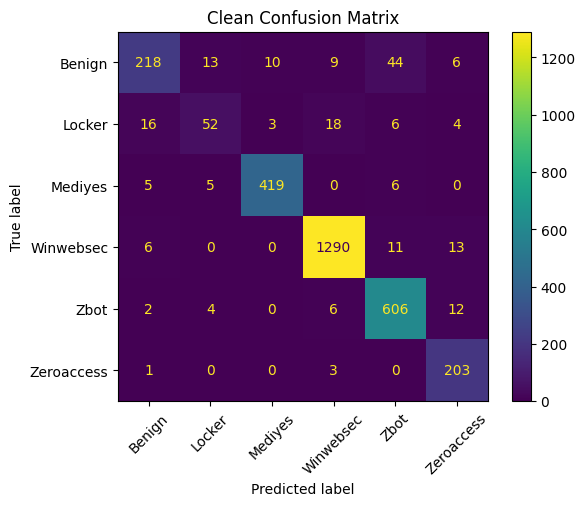

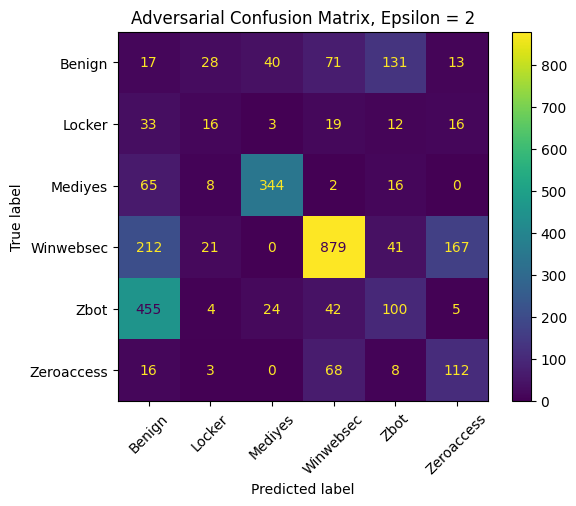

In [19]:
# ==============================
# Confusion Matrices
# ==============================

epsilon_to_plot = 2

labels_np, clean_preds_np, adv_preds_np = get_clean_and_adv_predictions(
    model, test_loader, epsilon_to_plot
)

class_names = list(test_data.class_to_idx.keys())

# Clean confusion matrix
clean_cm = confusion_matrix(labels_np, clean_preds_np)

disp = ConfusionMatrixDisplay(
    confusion_matrix=clean_cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45)
plt.title("Clean Confusion Matrix")
plt.show()

# Adversarial confusion matrix
adv_cm = confusion_matrix(labels_np, adv_preds_np)

disp = ConfusionMatrixDisplay(
    confusion_matrix=adv_cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45)
plt.title(f"Adversarial Confusion Matrix, Epsilon = {epsilon_to_plot}")
plt.show()

In [20]:
# ==============================
# Per-Class Classification Reports
# ==============================

print("Clean Classification Report")
print(classification_report(labels_np, clean_preds_np, target_names=class_names))

print(f"Adversarial Classification Report, Epsilon = {epsilon_to_plot}")
print(classification_report(labels_np, adv_preds_np, target_names=class_names))

Clean Classification Report
              precision    recall  f1-score   support

      Benign       0.88      0.73      0.80       300
      Locker       0.70      0.53      0.60        99
     Mediyes       0.97      0.96      0.97       435
   Winwebsec       0.97      0.98      0.98      1320
        Zbot       0.90      0.96      0.93       630
  Zeroaccess       0.85      0.98      0.91       207

    accuracy                           0.93      2991
   macro avg       0.88      0.86      0.86      2991
weighted avg       0.93      0.93      0.93      2991

Adversarial Classification Report, Epsilon = 2
              precision    recall  f1-score   support

      Benign       0.02      0.06      0.03       300
      Locker       0.20      0.16      0.18        99
     Mediyes       0.84      0.79      0.81       435
   Winwebsec       0.81      0.67      0.73      1320
        Zbot       0.32      0.16      0.21       630
  Zeroaccess       0.36      0.54      0.43       207

  

Paper for reference:
https://arxiv.org/pdf/1710.09435v1.pdf
